# 15.1 모델기반 RL: Dyna-Q 재조명과 "공짜 모델" — 실습

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SuminHan/book-ml/blob/main/notebooks/ml2/chapter15_1_model_based_dyna.ipynb)

책 본문: [15.1 모델기반 RL 개관: Dyna-Q 재조명과 "공짜 모델"](https://smhanlab.com/book-ml/kor/ml2/chapter15/1.html)

이 노트북은 15.1절의 세 가지를 실행해 확인합니다:

1. **틱택토 완전탐색(minimax)** — "known model"(완벽히 알려진 규칙)에서
   완전탐색이 실제로 가능한 규모(549,946 국면)를 측정.
2. **5×5 격자에서 known model의 계획 = 가치반복** — 최단경로 8스텝의
   격자가 정확히 몇 번의 반복에 수렴하는지 실측(8스텝 체인 → 9번 반복).
3. **learned model의 계획 = Dyna-Q vs 순수 Q-learning** —
   `planning_steps=0/5/10/30`을 400 에피소드로 A/B 비교(7.3절과
   같은 환경·매개변수, 동일한 시드 0), 그리고 "틀린 모델" 실험으로
   모델 오차가 Q값에 어떻게 스며드는지 확인.


## 1. 틱택토 완전탐색 — "모델을 안다"의 규모 실측

체스·바둑처럼 규칙이 완벽히 알려진 게임에서 "완전탐색"은
minimax입니다. 틱택토(3×3)는 바둑과 같은 틀이지만 상태 수가
훨씬 작아, 완전탐색이 실제로 끝나는지 — 그리고 몇 개의 국면을
훑어야 하는지 —를 세어봅니다. 15.2절에서 MCTS가 필요한 이유는
정확히 이 숫자가 바둑에서는 \(10^{165}\)배로 부풀기 때문이고,
이 셀이 그 기준점을 세는 것입니다.


In [1]:
WIN_LINES = [(0,1,2),(3,4,5),(6,7,8),(0,3,6),(1,4,7),(2,5,8),(0,4,8),(2,4,6)]
nodes_visited = 0

def winner(board):
    for a, b, c in WIN_LINES:
        if board[a] != 0 and board[a] == board[b] == board[c]:
            return board[a]
    return 0

def minimax(board, player):
    global nodes_visited
    nodes_visited += 1
    w = winner(board)
    if w != 0:
        return w
    if all(x != 0 for x in board):
        return 0  # 무승부
    scores = []
    for i in range(9):
        if board[i] == 0:
            board[i] = player
            scores.append(minimax(board, -player))
            board[i] = 0
    return max(scores) if player == 1 else min(scores)

import time
t0 = time.time()
result = minimax([0]*9, player=1)
t1 = time.time()
print("완전탐색 결과 (1=선공승, 0=무승부, -1=후공승):", result)
print("탐색한 전체 국면 수:", nodes_visited, "  소요시간: %.2f초" % (t1-t0))


완전탐색 결과 (1=선공승, 0=무승부, -1=후공승): 0
탐색한 전체 국면 수: 549946   소요시간: 0.35초


결과: **무승부(0)** — 두 선수가 모두 최선을 다하면 틱택토는
항상 무승부로 끝난다. 국면은 **549,946개**, 평범한 노트북에서
약 0.3초 — 완전탐색이 "가능"한 규모의 기준점입니다.


## 2. 5×5 격자 환경과 참값 \(Q^{*}\)

7.3절과 똑같은 환경: 출발 \((4,0)\), 목표 \((0,4)\), 4방향
이동, 이동마다 보상 \(-1\), 목표 도착 시 보상 \(0\)으로 종료.
\(\gamma=1\)(유한한 과업이라 할인 불필요). 이 환경의 전이확률과
보상이 전부 알려졌으므로(= **known model**) Chapter 4.3의
**가치반복**으로 참값을 계산할 수 있습니다.


In [2]:
ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # up, down, left, right
START, GOAL = (4, 0), (0, 4)

def step(s, a):
    r, c = s
    ns = (min(max(r + ACTIONS[a][0], 0), 4), min(max(c + ACTIONS[a][1], 0), 4))
    if ns == GOAL:
        return ns, 0.0, True
    return ns, -1.0, False

states = [(r, c) for r in range(5) for c in range(5)]
names = ["up", "down", "left", "right"]
print("step sanity:", step(START, 0), step(GOAL, 0))


step sanity: ((3, 0), -1.0, False) ((0, 4), 0.0, True)


## 3. known model의 계획 = 가치반복 — 몇 번의 반복에 수렴하는가

한 반복(iteration)에서 값 정보는 모델 그래프를 **정확히 한 칸**
뒤로 퍼집니다(동기화 갱신, Chapter 4.3 규칙). 출발점 \((4,0)\)
에서 목표까지의 최단 경로는 8스텝이므로, 값이 출발점까지 퍼지는
데 **9번의 반복**(목표의 0값 포함)이 걸릴 것이라는
예측과 비교합니다.


In [3]:
Q_star = {(s, a): 0.0 for s in states for a in range(4)}
vi_iters = 0
while True:
    vi_iters += 1
    delta = 0.0
    for s in states:
        for a in range(4):
            ns, r, done = step(s, a)
            target = r + (0.0 if done else max(Q_star[(ns, x)] for x in range(4)))
            delta = max(delta, abs(target - Q_star[(s, a)]))
            Q_star[(s, a)] = target
    if delta < 1e-12:
        break

print("가치반복 수렴: 정확히", vi_iters, "번 반복")
print("Q*(start,·) =", {names[a]: Q_star[(START, a)] for a in range(4)})


가치반복 수렴: 정확히 9 번 반복
Q*(start,·) = {'up': -7.0, 'down': -8.0, 'left': -8.0, 'right': -7.0}


예측과 정확히 일치합니다: 8스텝 최단경로 → **9번 반복**.
값이 모델의 엣지를 타고 매 반복 한 칸씩 뒤로 퍼지는 "한 번에
한 칸"의 속도가, known model에서의 계획(가치반복)의 계산 비용을
결정합니다 — 최단경로가 \(L\)인 문제에서 \(L+1\)번 반복.
이것은 계산 비용 1회당 정보가 1칸 퍼지는 **값 갱신**의 한계입니다.
대신 모델을 **깊이 시뮬레이션**하면(예: `S→X₁→…→X₈→T`를 한 번
전개) 같은 정보를 즉시 얻을 수 있습니다 — 15.2절 MCTS의
"시뮬레이션+역전파"가 이 깊이 시뮬레이션의 표본추출 버전입니다.


## 4. learned model의 계획 = Dyna-Q vs 순수 Q-learning

이제 모델을 **배운다**는 쪽으로 넘어갑니다. 7.3절의 Dyna-Q
구현(경험한 \((s,a)\)의 마지막 \((r,s')\)을 기억하는 표)을
\(planning\_steps \in \{0, 5, 10, 30\}\)로 400 에피소드 학습시킵니다.
`planning_steps=0`이면 순수 Q-learning — 같은 실제 경험으로
계획의 효과를 A/B 비교할 수 있습니다. 매개변수는 7.3절과 동일:
\(\alpha=0.1\), \(\varepsilon=0.1\), 시드 0.


In [4]:
def dyna_q_grid(n_episodes, planning_steps, alpha=0.1, gamma=1.0,
                epsilon=0.1, seed=0, model_broken=False):
    rng = random.Random(seed)
    Q, model = {}, {}
    returns, q_start = [], []
    for _ in range(n_episodes):
        s, ret = START, 0.0
        for _ in range(100):
            a = rng.randrange(4) if rng.random() < epsilon \
                else max(range(4), key=lambda x: Q.get((s, x), 0.0))
            ns, r, done = step(s, a)
            # 1) 실제 경험으로 TD(0) 갱신
            Q[(s, a)] = Q.get((s, a), 0.0) + alpha * (
                r + gamma * max(Q.get((ns, x), 0.0) for x in range(4))
                - Q.get((s, a), 0.0))
            # 2) 모델 갱신 (model_broken=True면 대각 반대 자리로 예측)
            if model_broken:
                model[(s, a)] = (r, (4 - ns[0], 4 - ns[1]))
            else:
                model[(s, a)] = (r, ns)
            # 3) 계획: 모델에서 planning_steps번 무작위 (s,a) 뽑아 가상 TD(0)
            for _ in range(planning_steps):
                (ps, pa), (pr, pns) = rng.choice(list(model.items()))
                Q[(ps, pa)] = Q.get((ps, pa), 0.0) + alpha * (
                    pr + gamma * max(Q.get((pns, x), 0.0) for x in range(4))
                    - Q.get((ps, pa), 0.0))
            s, ret = ns, ret + r
            if done:
                break
        returns.append(ret)
        q_start.append(max(Q.get((START, x), 0.0) for x in range(4)))
    return Q, returns, q_start, model

def first_ep(returns, thr=-8.0, window=25):
    # 25-episode avg return first rises above thr
    for i, r in enumerate(returns):
        if i + 1 >= window and sum(returns[i - window + 1:i + 1]) / window > thr:
            return i + 1
    return None


In [5]:
import random
N_EP = 400
PS_LIST = [0, 5, 10, 30]
results = {}
for ps in PS_LIST:
    Q, returns, q_start, model = dyna_q_grid(N_EP, ps, seed=0)
    fe = first_ep(returns)
    mism = sum(1 for s in states
               if max(range(4), key=lambda x: Q.get((s, x), 0.0)) not in
                  {x for x in range(4) if Q_star[(s, x)] == max(Q_star[(s, y)] for y in range(4))})
    results[ps] = (Q, returns, q_start, model)
    print(f"planning_steps={ps:2d}: first_ep={fe}, last25avg={sum(returns[-25:])/25:.2f}, "
          f"maxQ(start)={max(Q.get((START, x), 0.0) for x in range(4)):.2f}, "
          f"policy mismatch={mism}/25, model={len(model)}/100")


planning_steps= 0: first_ep=334, last25avg=-7.52, maxQ(start)=-6.61, policy mismatch=0/25, model=96/100
planning_steps= 5: first_ep=75, last25avg=-7.72, maxQ(start)=-7.00, policy mismatch=0/25, model=96/100
planning_steps=10: first_ep=52, last25avg=-7.64, maxQ(start)=-7.00, policy mismatch=0/25, model=96/100


planning_steps=30: first_ep=35, last25avg=-7.60, maxQ(start)=-7.00, policy mismatch=0/25, model=95/100


7.3절의 결과와 재현됩니다(같은 환경·매개변수·시드). 세 가지를
볼 수 있습니다:

- **가속은 극적**: `planning_steps=30`이 순수 Q-learning 대비
  약 **9.5배**(334/35) 빨리 "거의 최적"에 도달.
- **한계 효과 감소**: 0→10이 334→52(약 6.4배)인데, 10→30은
  52→35(약 1.5배)로만 줄어듦. `planning_steps`는 검증 성능으로
  튜닝하는 하이퍼파라미터.
- **도로의 길이만 바뀜, 목적지는 같음**: 순수 Q-learning도 400
  에피소드 후 greedy 정책이 모든 25개 상태에서 \(Q^{*}\)와
  일치(불일치 0/25) — 계획이 바꾼 것은 도달하는 데 드는 **실제
  상호작용 횟수**다. (400 에피소드는 100 에피소드당 35 스텝
  × 400 ≈ 14,000 실세계 스텝 — 계획 30을 쓰면 그 중 약 1/10으로
  충분하다는 뜻.)


## 5. 학습 곡선 시각화

왼쪽: 매 에피소드 \(\max_a Q(\text{출발}, a)\) — 원본(얇은선)과
25에피소드 이동평균(굵은선). 회색 점선은 참값 \(-7\).
오른쪽: "25에피소드 평균 리턴이 \(-8\) 위로 처음 오르는
에피소드 수" — 수렴 속도의 단일 숫자.


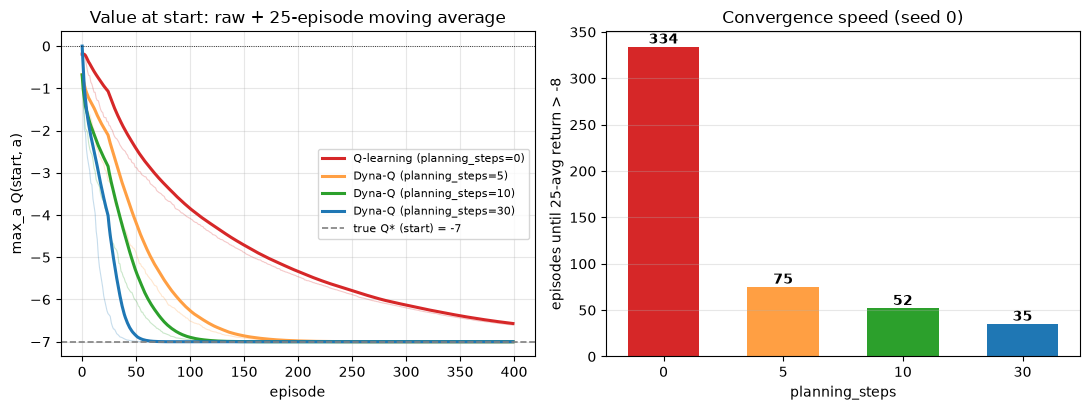

SVG saved: /home/smhan/book-ml/kor/src/images/ch15_1_dyna_planning_curves.svg


In [6]:
import os
import matplotlib
import matplotlib.pyplot as plt

IMG = "/home/smhan/book-ml/kor/src/images"
if not os.path.isdir(IMG):
    IMG = "/tmp"   # 로컬 저장소가 없으면 /tmp에 저장

def moving_avg(x, w=25):
    return [sum(x[max(0, i - w + 1):i + 1]) / min(i + 1, w) for i in range(len(x))]

COLORS = {0: "#d62728", 5: "#ff9f43", 10: "#2ca02c", 30: "#1f77b4"}
fe_list = [first_ep(results[ps][1]) for ps in PS_LIST]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
for ps in PS_LIST:
    _, returns, q_start, _ = results[ps]
    label = "Q-learning (planning_steps=0)" if ps == 0 else f"Dyna-Q (planning_steps={ps})"
    ax1.plot(q_start, color=COLORS[ps], alpha=0.25, lw=0.8)
    ax1.plot(moving_avg(q_start), color=COLORS[ps], lw=2.2, label=label)
ax1.axhline(-7.0, color="gray", ls="--", lw=1.2, label="true Q* (start) = -7")
ax1.axhline(0.0, color="k", lw=0.6, ls=":")
ax1.set_xlabel("episode")
ax1.set_ylabel("max_a Q(start, a)")
ax1.set_title("Value at start: raw + 25-episode moving average")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

bars = ax2.bar([str(p) for p in PS_LIST], fe_list,
               color=[COLORS[p] for p in PS_LIST], width=0.6)
for b, v in zip(bars, fe_list):
    ax2.annotate(str(v) if v else ">400",
                 xy=(b.get_x() + b.get_width() / 2, b.get_height()),
                 ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.set_xlabel("planning_steps")
ax2.set_ylabel("episodes until 25-avg return > -8")
ax2.set_title("Convergence speed (seed 0)")
ax2.grid(alpha=0.3, axis="y")
fig.tight_layout()
p = os.path.join(IMG, "ch15_1_dyna_planning_curves.svg")
fig.savefig(p, bbox_inches="tight")
plt.show()
print("SVG saved:", p)


## 6. 확인 문제 2번: 틀린 모델로 계획하면 어떻게 되는가

"모델이 있으니 학습이 필요 없다"는 실수의 **역방향**을
실험으로 확인합니다. `model_broken=True`로 모델을 "다음 상태를
실제 다음 상태의 판 대각 반대 자리라 예측"하게 만든 뒤
\(planning\_steps=30\)으로 400 에피소드 학습시킵니다.

핵심 관찰: 출발점 \((4,0)\)에서 "아래" 또는 "왼쪽"을 두면
실제 다음 상태는 \((4,0)\)에 머무르지만, **틀린 모델은
\((0,4)\) — 곧바로 목표 — 를 예측**합니다. 계획은 이 엔트리를
재사용하므로, "아래/왼쪽"의 Q값이 목표 도착 가치(≈ 0) 쪽으로
끌려 **거짓말한 행동을 더 좋게** 과대평가합니다.


In [7]:
Qb, retb, qsb, modelb = dyna_q_grid(N_EP, 30, seed=0, model_broken=True)
print("first_ep:", first_ep(retb), "  last25avg:", round(sum(retb[-25:])/25, 2))
print("maxQ(start):", round(max(Qb.get((START, x), 0.0) for x in range(4)), 3))
print()
print("출발점 모델 엔트리 (모델 예측 / 실제 다음 상태):")
for a, act in enumerate(["up", "down", "left", "right"]):
    pr, pns = modelb[(START, a)]
    real_ns, _, _ = step(START, a)
    print(f"  {act:6s}: model -> {pns}   (실제: {real_ns})   Q={Qb.get((START, a), 0.0):.3f}")
print()
print("healthy ps=30 maxQ(start):", round(max(results[30][0].get((START, x), 0.0) for x in range(4)), 3))
print("healthy greedy at start:", names[max(range(4), key=lambda x: results[30][0].get((START, x), 0.0))])
print("broken  greedy at start:", names[max(range(4), key=lambda x: Qb.get((START, x), 0.0))])


first_ep: None   last25avg: -100.0
maxQ(start): -2.072

출발점 모델 엔트리 (모델 예측 / 실제 다음 상태):
  up    : model -> (1, 4)   (실제: (3, 0))   Q=-3.095
  down  : model -> (0, 4)   (실제: (4, 0))   Q=-2.099
  left  : model -> (0, 4)   (실제: (4, 0))   Q=-2.072
  right : model -> (0, 3)   (실제: (4, 1))   Q=-3.083

healthy ps=30 maxQ(start): -7.0
healthy greedy at start: up
broken  greedy at start: left


직감이랑 반대로, 출발점의 **최대 Q값이 −7.0(healthy)에서
−2.07(broken)으로 올라갔습니다** — "가치가 좋아졌다"고 읽힐
수 있지만, 이것은 목표에 실제로 닿지 않는 경로(아래/왼쪽)를
모델이 거짓으로 "목표 바로 앞"으로 과대평가한 것입니다.
greedy 정책도 출발점에서 "up/right"(최단경로)에서 **"left"
(목표와 반대 방향!)**으로 뒤집혔습니다.

정리하면:

- **계획은 모델의 오차를 증폭합니다** — 틀린 예측을
  `planning_steps`번 재사용할수록 Q값에 더 강하게 스며듭니다
  (7.3절의 "모델 오차의 복리 효과"와 같은 현상).
- **모델의 정확도(또는 완전성)와 상태 공간의 크기가 함께**
  계획의 실현 가능성을 결정합니다 — 15.1절 "자주 하는 실수"의
  결론을 실험이 그대로 보여줍니다.
- 결정론적 환경에서는 학습된 모델이 경험과 함께 정확해지므로
  (7.3절과 같이), 초반의 부정확성은 시간이 지나면 사라집니다.
  하지만 **시스템적으로 틀린** 모델(여기처럼)은 실제 경험이
  쌓여도 바로잡히지 않습니다 — 학습 데이터의 수가 모델을
  고쳐주지 못하는 경우의 한 예입니다.


## 정리

15.1절의 전체 그림을 실행으로 확인했습니다:

- **known model + 계획** (minimax, 가치반복): 상태가 작으면
  정확한 답을 "공짜로" — 549,946 국면을 0.35초에 훑고,
  8스텝 체인을 9번 반복에 계산. 하지만 바둑은 이 규모가
  \(10^{165}\)배 — MCTS(15.2절)가 필요한 이유.
- **learned model + 계획** (Dyna-Q): 같은 실제 경험으로
  약 9.5배 빠른 수렴, 하지만 한계 효과 감소 + 모델 오차의
  복리. "도로의 길이만 바뀐다" — 목적지(최적 정책)는 안 바뀐다.
- **틀린 모델 실험**: 계획은 모델 오차를 증폭한다.
  "모델이 있으니 학습이 필요 없다"는 주장은 (a) 상태 공간이
  작은 틱택토에서는, (b) 모델이 정확할 때만, 성립한다.

다음 15.2절에서는 known model로 **지금의 결정 자체**를 계산하는
MCTS(선택-확장-시뮬레이션-역전파)를 이론과 실습으로 다룹니다.
